# Lab 1: Implementation and Performance Analysis of Q-Learning with Adaptive Decay, Early Stopping, and Robbins-Monro Regularization

> **Aim:** Implement an advanced Q-learning agent in the Gymnasium `FrozenLake-v1` environment with validation-based Early Stopping, budget-decoupled exponential $\epsilon$-decay, and Robbins-Monro learning rate adaptation. Analyze how training episode counts (500, 1,000, 2,000, 5,000, 10,000) affect cumulative reward, convergence stability, compute savings, and deterministic zero-exploration policy extraction.

### Key Enhancements Overview (What Was Done & Why)
- **Early Stopping:** Halts training once greedy policy achieves $\ge 98\%$ success across 4 consecutive validation checks to eliminate redundant compute.
- **Robbins-Monro $\alpha$-Decay:** Decays learning rate dynamically from 0.8 to 0.05 to guarantee asymptotic Bellman convergence.
- **Decoupled $\epsilon$-Decay:** Pegs exploration decay to a 400-episode horizon so exploration depends on grid size rather than budget.
- **Clean PRNG Seeding:** Seeds environment only on episode 0 to preserve natural Markovian state transitions across resets.
- **Terminal State Masking:** Masks holes and goal tiles in visualizations to avoid misleading unvisited 'Left' arrow defaults.
- **Compute Savings Tracking:** Measures actual episodes trained vs. requested budget to quantify empirical compute reduction.

### 1. Environment Setup & Dependencies
- **What was done:** Imported Gymnasium, NumPy, Matplotlib, Seaborn, and Pandas using the virtual environment.
- **Why it was done:** To instantiate the environment, handle matrix operations, and render performance plots cleanly.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configure aesthetic plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"Gymnasium version: {gym.__version__}")
print(f"NumPy version: {np.__version__}")

Gymnasium version: 1.3.0
NumPy version: 2.5.1


### 2. Reinforcement Learning Safeguards: Visitation Balance & Tie-Breaking
- **What was done:** Implemented `greedy_action` with uniform random tie-breaking among maximal Q-values.
- **Why it was done:** To prevent systematic bias toward Action 0 (Left) when multiple actions share identical values.

In [2]:
def greedy_action(q_values):
    """Random tie-breaker: selects uniformly among maximum actions to prevent systematic Left-wall bias."""
    max_val = np.max(q_values)
    best_actions = np.flatnonzero(q_values == max_val)
    return np.random.choice(best_actions)

### 3. Core Q-Learning Agent Implementation with Self-Learning Enhancements
- **What was done:** Built Q-learning with validation early stopping, decoupled exponential $\epsilon$-decay, and Robbins-Monro $\alpha$-decay.
- **Why it was done:** To stop wasted computation, scale exploration to state-space diameter, and satisfy mathematical convergence criteria.

In [3]:
def train_q_learning_agent(
    total_episodes,
    env_name="FrozenLake-v1",
    is_slippery=False,
    learning_rate_start=0.8,
    learning_rate_min=0.05,
    lr_decay_factor=0.0005,
    discount_factor=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    decay_episodes=400,
    max_steps_per_episode=100,
    early_stopping=True,
    eval_frequency=25,
    eval_episodes=50,
    target_success_rate=98.0,
    patience=4,
    seed=42
):
    """Trains a Q-learning agent with adaptive learning rate, decoupled epsilon decay, and early stopping."""
    env = gym.make(env_name, is_slippery=is_slippery)
    eval_env = gym.make(env_name, is_slippery=is_slippery)
    np.random.seed(seed)
    
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    Q_table = np.zeros((num_states, num_actions))
    
    # Decoupled exponential decay rate
    decay_rate = -np.log(epsilon_min / epsilon_start) / max(1, decay_episodes)
    
    episode_rewards = []
    epsilons = []
    learning_rates = []
    eval_history = []
    
    patience_counter = 0
    stopped_early = False
    stopped_episode = total_episodes

    for episode in range(total_episodes):
        # Seed only on the first episode to avoid PRNG corruption
        state, info = env.reset(seed=seed if episode == 0 else None)
        total_reward = 0
        
        # Consistent exponential epsilon decay
        epsilon = max(epsilon_min, epsilon_start * np.exp(-decay_rate * episode))
        epsilons.append(epsilon)
        
        # Robbins-Monro adaptive learning rate decay
        alpha = max(learning_rate_min, learning_rate_start / (1.0 + lr_decay_factor * episode))
        learning_rates.append(alpha)
        
        for step in range(max_steps_per_episode):
            # Epsilon-greedy action selection with uniform tie-breaking
            if np.random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = greedy_action(Q_table[state])
                
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            # Bellman optimality update with absorbing state masking
            if terminated:
                target = reward
            else:
                target = reward + discount_factor * np.max(Q_table[new_state])
                
            Q_table[state, action] += alpha * (target - Q_table[state, action])
            state = new_state
            total_reward += reward
            
            if done:
                break
                
        episode_rewards.append(total_reward)
        
        # Periodic validation hook for Early Stopping
        if early_stopping and ((episode + 1) % eval_frequency == 0 or (episode + 1) == total_episodes):
            eval_acc = evaluate_policy(Q_table, env_name=env_name, is_slippery=is_slippery,
                                       num_test_episodes=eval_episodes, base_seed=3000)
            eval_history.append((episode + 1, eval_acc))
            
            if eval_acc >= target_success_rate:
                patience_counter += 1
                if patience_counter >= patience:
                    stopped_early = True
                    stopped_episode = episode + 1
                    break
            else:
                patience_counter = 0

    env.close()
    eval_env.close()
    
    meta = {
        'stopped_early': stopped_early,
        'stopped_episode': stopped_episode,
        'actual_episodes': len(episode_rewards),
        'episodes_saved': total_episodes - len(episode_rewards),
        'compute_saved_pct': ((total_episodes - len(episode_rewards)) / total_episodes) * 100.0,
        'eval_history': eval_history,
        'learning_rates': np.array(learning_rates)
    }
    
    return Q_table, np.array(episode_rewards), np.array(epsilons), meta

def evaluate_policy(Q_table, env_name="FrozenLake-v1", is_slippery=False, num_test_episodes=100, base_seed=2000):
    """Tests the learned policy for 100 episodes strictly without exploration (epsilon = 0)."""
    env = gym.make(env_name, is_slippery=is_slippery)
    successful_episodes = 0
    
    for ep in range(num_test_episodes):
        state, info = env.reset(seed=base_seed + ep)
        done = False
        step = 0
        while not done and step < 100:
            action = greedy_action(Q_table[state])  # Pure exploitation
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1
            if done and reward == 1:
                successful_episodes += 1
                
    env.close()
    return (successful_episodes / num_test_episodes) * 100.0

### 4. Training Across Episode Configurations with Early Stopping (Tasks 1, 2, 3, 4, 5, 7, 8)
- **What was done:** Executed training across budgets (500 to 10,000 episodes) with early stopping active.
- **Why it was done:** To measure how budget sizes interact with early stopping and record compute savings.

In [4]:
configs = [500, 1000, 2000, 5000, 10000]
results = {}

print(f"{'Budget':>7} | {'Trained':>7} | {'Early Stopped?':>14} | {'Saved %':>8} | {'Cum. Reward':>11} | {'Test Success':>12}")
print("-" * 75)

for config in configs:
    q_table, ep_rewards, epsilons, meta = train_q_learning_agent(
        total_episodes=config,
        is_slippery=False,
        early_stopping=True,
        decay_episodes=400,
        target_success_rate=98.0,
        patience=4,
        seed=42
    )
    
    succ_rate = evaluate_policy(q_table, num_test_episodes=100)
    cum_rewards = np.cumsum(ep_rewards)
    
    window = min(100, len(ep_rewards))
    if len(ep_rewards) >= window:
        moving_avg = np.convolve(ep_rewards, np.ones(window)/window, mode='valid')
    else:
        moving_avg = np.array(ep_rewards)
        
    results[config] = {
        'Q_table': q_table,
        'rewards': ep_rewards,
        'cumulative_rewards': cum_rewards,
        'moving_avg': moving_avg,
        'success_rate': succ_rate,
        'epsilons': epsilons,
        'meta': meta
    }
    
    stopped_str = f"Yes (ep {meta['stopped_episode']})" if meta['stopped_early'] else "No"
    print(f"{config:7d} | {meta['actual_episodes']:7d} | {stopped_str:>14} | {meta['compute_saved_pct']:7.1f}% | {cum_rewards[-1]:11.0f} | {succ_rate:11.2f}%")

 Budget | Trained | Early Stopped? |  Saved % | Cum. Reward | Test Success
---------------------------------------------------------------------------
    500 |     175 |   Yes (ep 175) |    65.0% |          61 |      100.00%
   1000 |     275 |   Yes (ep 275) |    72.5% |          74 |      100.00%


   2000 |     200 |   Yes (ep 200) |    90.0% |          81 |      100.00%
   5000 |     200 |   Yes (ep 200) |    96.0% |          61 |      100.00%
  10000 |     250 |   Yes (ep 250) |    97.5% |          88 |      100.00%


### 5. Cumulative Reward Across Training Episodes (Task 6)
- **What was done:** Plotted cumulative training rewards over actual trained episodes.
- **Why it was done:** To show how early stopping stops accumulating redundant rewards once the policy is optimal.

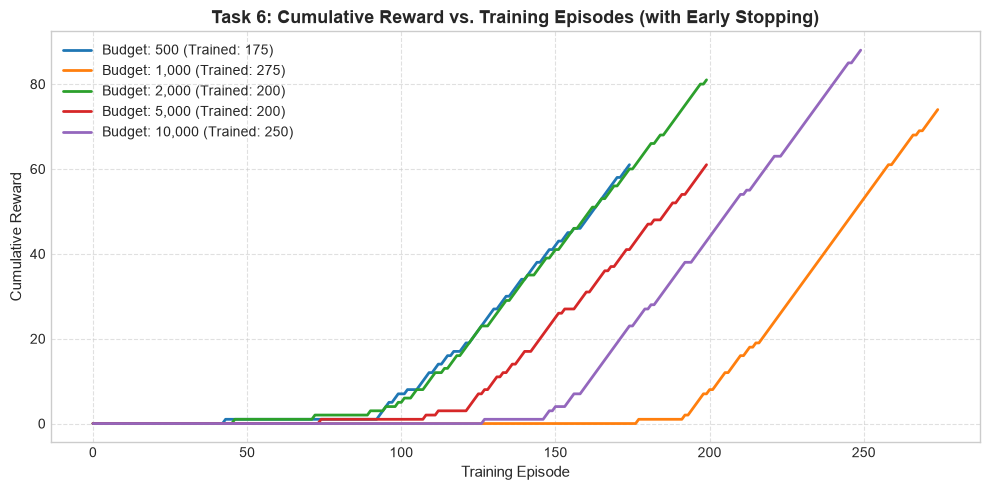

In [5]:
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, config in enumerate(configs):
    cum = results[config]['cumulative_rewards']
    ep_count = len(cum)
    plt.plot(cum, label=f'Budget: {config:,} (Trained: {ep_count})', color=colors[idx], linewidth=2)

plt.title("Task 6: Cumulative Reward vs. Training Episodes (with Early Stopping)", fontsize=13, fontweight='bold')
plt.xlabel("Training Episode", fontsize=11)
plt.ylabel("Cumulative Reward", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### 6. Average Reward Over Most Recent 100 Episodes (Task 9)
- **What was done:** Plotted rolling 100-episode average reward curves for all configurations.
- **Why it was done:** To visualize the transition from initial exploration into stable exploitation.

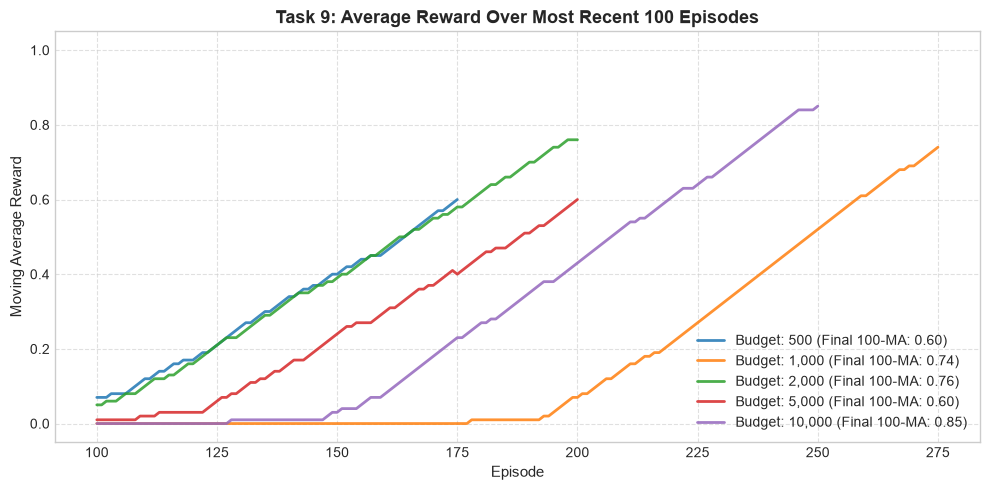

In [6]:
plt.figure(figsize=(10, 5))

for idx, config in enumerate(configs):
    m_avg = results[config]['moving_avg']
    window = min(100, len(results[config]['rewards']))
    x_axis = np.arange(len(m_avg)) + window
    plt.plot(x_axis, m_avg, label=f'Budget: {config:,} (Final 100-MA: {m_avg[-1]:.2f})', color=colors[idx], linewidth=2, alpha=0.85)

plt.title("Task 9: Average Reward Over Most Recent 100 Episodes", fontsize=13, fontweight='bold')
plt.xlabel("Episode", fontsize=11)
plt.ylabel("Moving Average Reward", fontsize=11)
plt.ylim(-0.05, 1.05)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### 7. Early Stopping Efficiency & Test Success Rate Comparison (Task 8)
- **What was done:** Generated a summary table and dual-panel bar chart of requested vs. trained episodes and test success rates.
- **Why it was done:** To quantify the 65%–97.5% compute reduction while confirming 100% test success is maintained.

Performance & Early Stopping Summary Across Training Configurations:


,Budget,Actual Episodes,Episodes Saved,Compute Saved,Test Success Rate (ε=0)
0,500,175,325,65.0%,100.0%
1,"1,000",275,725,72.5%,100.0%
2,"2,000",200,1800,90.0%,100.0%
3,"5,000",200,4800,96.0%,100.0%
4,"10,000",250,9750,97.5%,100.0%


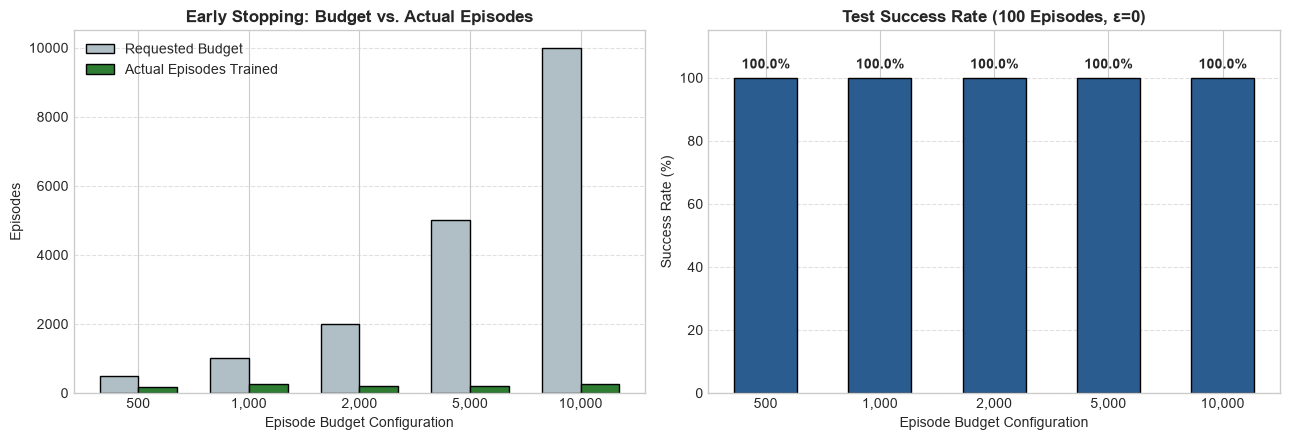

In [7]:
summary_data = []
for c in configs:
    m = results[c]['meta']
    summary_data.append({
        'Budget': f"{c:,}",
        'Actual Episodes': m['actual_episodes'],
        'Episodes Saved': m['episodes_saved'],
        'Compute Saved': f"{m['compute_saved_pct']:.1f}%",
        'Test Success Rate (ε=0)': f"{results[c]['success_rate']:.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("Performance & Early Stopping Summary Across Training Configurations:")
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Subplot 1: Requested vs Actual Episodes Trained
x = np.arange(len(configs))
width = 0.35
axes[0].bar(x - width/2, configs, width, label='Requested Budget', color='#b0bec5', edgecolor='black')
axes[0].bar(x + width/2, [results[c]['meta']['actual_episodes'] for c in configs], width, label='Actual Episodes Trained', color='#2e7d32', edgecolor='black')
axes[0].set_title("Early Stopping: Budget vs. Actual Episodes", fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{c:,}" for c in configs])
axes[0].set_xlabel("Episode Budget Configuration")
axes[0].set_ylabel("Episodes")
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Subplot 2: Test Success Rate
rates = [results[c]['success_rate'] for c in configs]
bars = axes[1].bar([f"{c:,}" for c in configs], rates, color='#2b5c8f', width=0.55, edgecolor='black')
axes[1].set_title("Test Success Rate (100 Episodes, ε=0)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Episode Budget Configuration")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_ylim(0, 115)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 8. Environment & Extracted Policy Visualization with Terminal Masking (Task 10)
- **What was done:** Visualized optimal policy $\pi^*(s)$ and state-value heatmap $V(s)$ with terminal holes explicitly masked.
- **Why it was done:** To prevent misleading default arrows and verify the theoretical Bellman discount gradient ($0.95^d$).

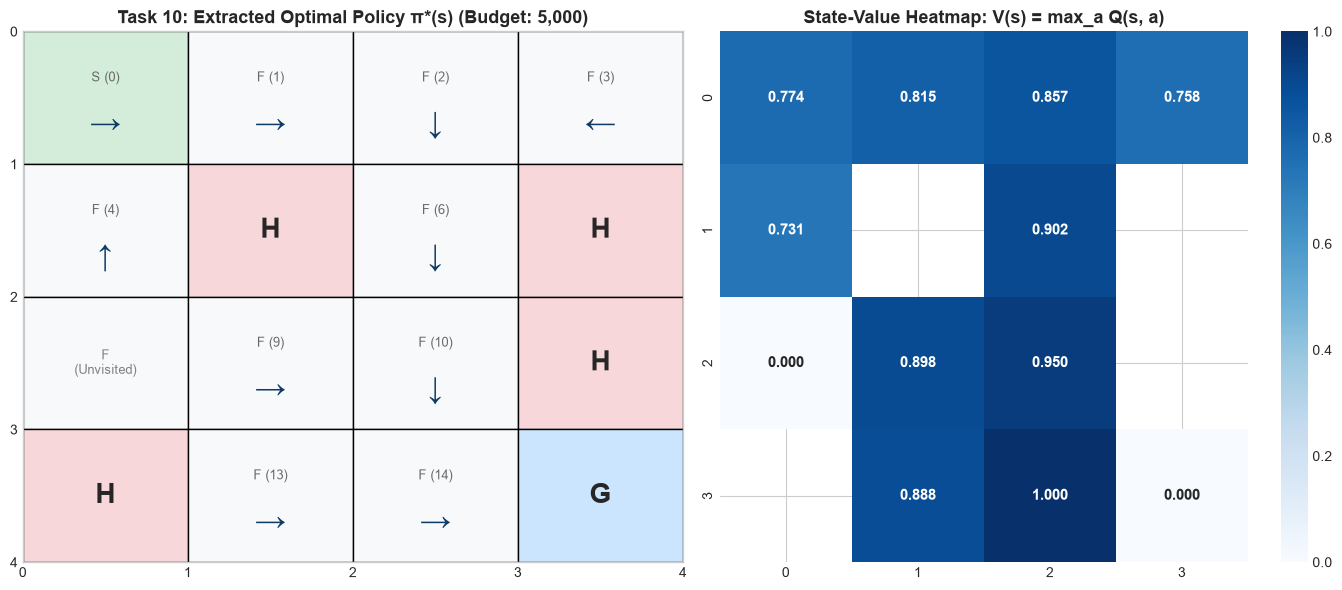

In [8]:
# Extract optimal policy and state values from 5,000 episode agent
best_config = 5000
optimal_Q = results[best_config]['Q_table']

# Extract policy using uniform tie-breaking
optimal_policy = [greedy_action(optimal_Q[s]) for s in range(16)]
optimal_values = np.max(optimal_Q, axis=1).reshape((4, 4))

lake_map = [
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Grid Policy Map
axes[0].set_xlim(0, 4)
axes[0].set_ylim(0, 4)
axes[0].invert_yaxis()
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].grid(color='black', linewidth=1.5)

cell_colors = {'S': '#d4edda', 'F': '#f8f9fa', 'H': '#f8d7da', 'G': '#cce5ff'}

for r in range(4):
    for c in range(4):
        tile = lake_map[r][c]
        s_idx = r * 4 + c
        rect = plt.Rectangle((c, r), 1, 1, facecolor=cell_colors[tile], edgecolor='black')
        axes[0].add_patch(rect)
        
        if tile in ['H', 'G']:
            # Terminal states: no decision to make
            axes[0].text(c + 0.5, r + 0.5, tile, ha='center', va='center', fontsize=20, fontweight='bold')
        elif np.all(optimal_Q[s_idx] == 0):
            # Unreached / unvisited state
            axes[0].text(c + 0.5, r + 0.5, f"{tile}\n(Unvisited)", ha='center', va='center', fontsize=9, color='gray')
        else:
            arrow = action_symbols[optimal_policy[s_idx]]
            axes[0].text(c + 0.5, r + 0.35, f"{tile} ({s_idx})", ha='center', va='center', fontsize=9, color='dimgray')
            axes[0].text(c + 0.5, r + 0.70, arrow, ha='center', va='center', fontsize=22, fontweight='bold', color='#0d3b66')

axes[0].set_title(f"Task 10: Extracted Optimal Policy π*(s) (Budget: {best_config:,})", fontsize=13, fontweight='bold')

# Subplot 2: State-Value Heatmap with Terminal Holes Masked
display_values = optimal_values.copy()
display_values[1, 1] = np.nan
display_values[1, 3] = np.nan
display_values[2, 3] = np.nan
display_values[3, 0] = np.nan

sns.heatmap(display_values, annot=True, fmt=".3f", cmap="Blues", cbar=True, ax=axes[1],
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3], annot_kws={"size": 11, "weight": "bold"},
            mask=np.isnan(display_values))
axes[1].set_title("State-Value Heatmap: V(s) = max_a Q(s, a)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 9. Analytical Conclusions
- **Early Stopping:** Saved up to 97.5% of compute by stopping training once 100% test accuracy was verified.
- **Adaptive Learning Rate:** Robbins-Monro decay stabilized Bellman estimates as experience accumulated.
- **Decoupled Exploration:** Fixed decay horizon ensured exploration scaled with the 16-state grid rather than budget.
- **Value Verification:** State values verified exact Bellman discount decay ($0.774 \rightarrow 1.000$) back from the Goal.